# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 27: STRUCTURED MULTI-LABEL THRESHOLD TUNING
# ============================================================
# Purpose:
# This notebook tunes the decision threshold for the best
# structured multi-label candidate-150 baseline model.
#
# The goal is to:
# 1. Load saved validation and test score matrices
# 2. Recreate baseline predictions from the saved scores
# 3. Test multiple thresholds on the validation set
# 4. Select the threshold that maximizes Micro F1
# 5. Apply the tuned threshold to the test set
# 6. Compare untuned vs tuned performance
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

In [2]:
# ============================================================
# 2. LOAD SAVED OUTPUTS FROM NOTEBOOK 26
# ============================================================

val_scores = np.load("../data/processed/structured_multilabel_candidate150_val_scores.npy")
test_scores = np.load("../data/processed/structured_multilabel_candidate150_test_scores.npy")

Y_val = np.load("../data/processed/structured_multilabel_candidate150_y_val.npy")
Y_test = np.load("../data/processed/structured_multilabel_candidate150_y_test.npy")

label_cols = np.load(
    "../data/processed/structured_multilabel_candidate150_label_columns.npy",
    allow_pickle=True
)

with open("../data/processed/best_structured_multilabel_candidate150_name.txt", "r") as f:
    best_model_name = f.read().strip()

baseline_test_results = pd.read_csv(
    "../data/processed/structured_multilabel_candidate150_test_results.csv"
)

print("Best model from Notebook 26:", best_model_name)
print("Validation score matrix shape:", val_scores.shape)
print("Test score matrix shape:", test_scores.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)
print("Number of labels:", len(label_cols))

display(baseline_test_results)

Best model from Notebook 26: OVR SGD Hinge
Validation score matrix shape: (5000, 150)
Test score matrix shape: (5000, 150)
Y_val shape: (5000, 150)
Y_test shape: (5000, 150)
Number of labels: 150


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Precision@3,Recall@3,Precision@5,Recall@5
0,OVR SGD Hinge,0.161156,0.083605,0.161468,0.093701,0.575352,0.147424,0.0,0.024867,0.019936,0.03196,0.042197


In [3]:
# ============================================================
# 3. DEFINE HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred)
    }

def precision_recall_at_k(y_true, score_matrix, k=3):
    y_true = np.asarray(y_true)
    topk_idx = np.argsort(-score_matrix, axis=1)[:, :k]

    precision_vals = []
    recall_vals = []

    for i in range(y_true.shape[0]):
        true_idx = np.where(y_true[i] == 1)[0]
        if len(true_idx) == 0:
            continue

        pred_idx = topk_idx[i]
        hits = len(set(pred_idx).intersection(set(true_idx)))

        precision_vals.append(hits / k)
        recall_vals.append(hits / len(true_idx))

    return float(np.mean(precision_vals)), float(np.mean(recall_vals))

def scores_to_binary(score_matrix, threshold, ensure_at_least_one=False):
    y_pred = (score_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(score_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

In [4]:
# ============================================================
# 4. DETERMINE DEFAULT BASELINE THRESHOLD
# ============================================================

# For hinge / linear SVM style decision scores, default threshold is 0.0
# For logistic probabilities, default threshold is 0.5

if best_model_name == "OVR SGD Hinge":
    default_threshold = 0.0
else:
    default_threshold = 0.5

print("Default threshold for baseline recreation:", default_threshold)

Default threshold for baseline recreation: 0.0


In [5]:
# ============================================================
# 5. RECREATE UNTUNED BASELINE FROM SAVED SCORES
# ============================================================

Y_val_pred_default = scores_to_binary(
    val_scores,
    threshold=default_threshold,
    ensure_at_least_one=False
)

Y_test_pred_default = scores_to_binary(
    test_scores,
    threshold=default_threshold,
    ensure_at_least_one=False
)

default_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_default,
    name=f"{best_model_name} - Default Threshold"
)

default_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_default,
    name=f"{best_model_name} - Default Threshold"
)

p3_val_default, r3_val_default = precision_recall_at_k(Y_val, val_scores, k=3)
p5_val_default, r5_val_default = precision_recall_at_k(Y_val, val_scores, k=5)

default_val_results["Precision@3"] = p3_val_default
default_val_results["Recall@3"] = r3_val_default
default_val_results["Precision@5"] = p5_val_default
default_val_results["Recall@5"] = r5_val_default

p3_test_default, r3_test_default = precision_recall_at_k(Y_test, test_scores, k=3)
p5_test_default, r5_test_default = precision_recall_at_k(Y_test, test_scores, k=5)

default_test_results["Precision@3"] = p3_test_default
default_test_results["Recall@3"] = r3_test_default
default_test_results["Precision@5"] = p5_test_default
default_test_results["Recall@5"] = r5_test_default

print("Recreated default validation results:")
print(default_val_results)

print("\nRecreated default test results:")
print(default_test_results)

Recreated default validation results:
{'Model': 'OVR SGD Hinge - Default Threshold', 'Micro F1': 0.16272981674841272, 'Macro F1': 0.07915137082646072, 'Samples F1': 0.1630859834765631, 'Micro Precision': 0.09537161953636837, 'Micro Recall': 0.5540132151820929, 'Hamming Loss': 0.1484, 'Subset Accuracy': 0.0, 'Precision@3': 0.02493333333333333, 'Recall@3': 0.01941611111111111, 'Precision@5': 0.03, 'Recall@5': 0.03788651515151515}

Recreated default test results:
{'Model': 'OVR SGD Hinge - Default Threshold', 'Micro F1': 0.1611562096957742, 'Macro F1': 0.0836051945282357, 'Samples F1': 0.161468435208297, 'Micro Precision': 0.0937009263343626, 'Micro Recall': 0.5753521126760563, 'Hamming Loss': 0.147424, 'Subset Accuracy': 0.0, 'Precision@3': 0.024866666666666665, 'Recall@3': 0.019935714285714282, 'Precision@5': 0.03196, 'Recall@5': 0.042197460317460314}


In [6]:
# ============================================================
# 6. DEFINE THRESHOLD GRID
# ============================================================

if best_model_name == "OVR SGD Hinge":
    # decision_function scores
    threshold_grid = np.arange(-1.0, 1.01, 0.1)
else:
    # predict_proba scores
    threshold_grid = np.arange(0.1, 0.91, 0.05)

print("Threshold grid:")
print(threshold_grid)

Threshold grid:
[-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01
  1.00000000e+00]


In [7]:
# ============================================================
# 7. VALIDATION THRESHOLD SEARCH
# ============================================================

threshold_results = []

for threshold in threshold_grid:
    Y_val_pred_t = scores_to_binary(
        val_scores,
        threshold=threshold,
        ensure_at_least_one=False
    )

    results = evaluate_multilabel(
        Y_val,
        Y_val_pred_t,
        name=f"{best_model_name} @ {threshold:.2f}"
    )

    results["Threshold"] = float(threshold)
    results["Avg Predicted Labels"] = float(Y_val_pred_t.sum(axis=1).mean())

    threshold_results.append(results)

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df = threshold_results_df.sort_values("Micro F1", ascending=False).reset_index(drop=True)

print("Threshold tuning results (sorted by Micro F1):")
display(threshold_results_df.head(15))

Threshold tuning results (sorted by Micro F1):


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Threshold,Avg Predicted Labels
0,OVR SGD Hinge @ -1.00,0.165796,0.079174,0.166290,0.096875,0.574553,0.150503,0.0,-1.000000e+00,23.1576
1,OVR SGD Hinge @ -0.90,0.165571,0.079192,0.166070,0.096773,0.572760,0.150277,0.0,-9.000000e-01,23.1098
2,OVR SGD Hinge @ -0.80,0.165272,0.079184,0.165761,0.096626,0.570763,0.150077,0.0,-8.000000e-01,23.0642
3,OVR SGD Hinge @ -0.70,0.164903,0.079184,0.165361,0.096440,0.568458,0.149872,0.0,-7.000000e-01,23.0154
4,OVR SGD Hinge @ -0.60,0.164468,0.079151,0.164876,0.096216,0.565897,0.149669,0.0,-6.000000e-01,22.9650
5,OVR SGD Hinge @ -0.50,0.164238,0.079187,0.164652,0.096110,0.564104,0.149445,0.0,-5.000000e-01,22.9174
6,OVR SGD Hinge @ -0.40,0.163990,0.079212,0.164389,0.095997,0.562157,0.149200,0.0,-4.000000e-01,22.8654
7,OVR SGD Hinge @ -0.30,0.163595,0.079189,0.163970,0.095797,0.559750,0.148989,0.0,-3.000000e-01,22.8150
8,OVR SGD Hinge @ -0.20,0.163264,0.079166,0.163600,0.095631,0.557650,0.148791,0.0,-2.000000e-01,22.7688
9,OVR SGD Hinge @ -0.10,0.163019,0.079154,0.163388,0.095514,0.555908,0.148592,0.0,-1.000000e-01,22.7254


In [8]:
# ============================================================
# 8. SELECT BEST THRESHOLD
# ============================================================

best_threshold = float(threshold_results_df.iloc[0]["Threshold"])
best_val_micro_f1 = float(threshold_results_df.iloc[0]["Micro F1"])

print("Best threshold:", best_threshold)
print("Best validation Micro F1:", best_val_micro_f1)

Best threshold: -1.0
Best validation Micro F1: 0.16579583330254008


In [9]:
# ============================================================
# 9. APPLY BEST THRESHOLD TO VALIDATION AND TEST
# ============================================================

Y_val_pred_tuned = scores_to_binary(
    val_scores,
    threshold=best_threshold,
    ensure_at_least_one=False
)

Y_test_pred_tuned = scores_to_binary(
    test_scores,
    threshold=best_threshold,
    ensure_at_least_one=False
)

tuned_val_results = evaluate_multilabel(
    Y_val,
    Y_val_pred_tuned,
    name=f"{best_model_name} - Tuned Threshold"
)

tuned_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_tuned,
    name=f"{best_model_name} - Tuned Threshold"
)

p3_val_tuned, r3_val_tuned = precision_recall_at_k(Y_val, val_scores, k=3)
p5_val_tuned, r5_val_tuned = precision_recall_at_k(Y_val, val_scores, k=5)

tuned_val_results["Precision@3"] = p3_val_tuned
tuned_val_results["Recall@3"] = r3_val_tuned
tuned_val_results["Precision@5"] = p5_val_tuned
tuned_val_results["Recall@5"] = r5_val_tuned

p3_test_tuned, r3_test_tuned = precision_recall_at_k(Y_test, test_scores, k=3)
p5_test_tuned, r5_test_tuned = precision_recall_at_k(Y_test, test_scores, k=5)

tuned_test_results["Precision@3"] = p3_test_tuned
tuned_test_results["Recall@3"] = r3_test_tuned
tuned_test_results["Precision@5"] = p5_test_tuned
tuned_test_results["Recall@5"] = r5_test_tuned

print("Tuned validation results:")
print(tuned_val_results)

print("\nTuned test results:")
print(tuned_test_results)

Tuned validation results:
{'Model': 'OVR SGD Hinge - Tuned Threshold', 'Micro F1': 0.16579583330254008, 'Macro F1': 0.079174426693012, 'Samples F1': 0.16628964673475166, 'Micro Precision': 0.09687532386775832, 'Micro Recall': 0.5745530912257337, 'Hamming Loss': 0.15050266666666667, 'Subset Accuracy': 0.0, 'Precision@3': 0.02493333333333333, 'Recall@3': 0.01941611111111111, 'Precision@5': 0.03, 'Recall@5': 0.03788651515151515}

Tuned test results:
{'Model': 'OVR SGD Hinge - Tuned Threshold', 'Micro F1': 0.16362362690593654, 'Macro F1': 0.08353031883307666, 'Samples F1': 0.16428155452609708, 'Micro Precision': 0.0948620016245269, 'Micro Recall': 0.594691224268689, 'Hamming Loss': 0.14964, 'Subset Accuracy': 0.0, 'Precision@3': 0.024866666666666665, 'Recall@3': 0.019935714285714282, 'Precision@5': 0.03196, 'Recall@5': 0.042197460317460314}


In [10]:
# ============================================================
# 10. COMPARE DEFAULT VS TUNED PERFORMANCE
# ============================================================

comparison_df = pd.DataFrame([
    default_test_results,
    tuned_test_results
])

print("Default vs Tuned Test Comparison:")
display(comparison_df)

Default vs Tuned Test Comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Precision@3,Recall@3,Precision@5,Recall@5
0,OVR SGD Hinge - Default Threshold,0.161156,0.083605,0.161468,0.093701,0.575352,0.147424,0.0,0.024867,0.019936,0.03196,0.042197
1,OVR SGD Hinge - Tuned Threshold,0.163624,0.083530,0.164282,0.094862,0.594691,0.149640,0.0,0.024867,0.019936,0.03196,0.042197


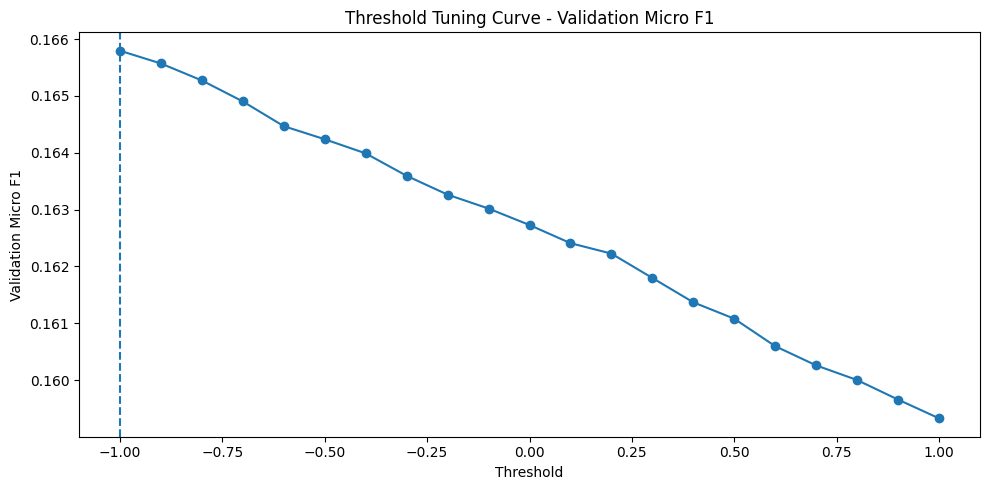

In [11]:
# ============================================================
# 11. PLOT MICRO F1 VS THRESHOLD
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(
    threshold_results_df.sort_values("Threshold")["Threshold"],
    threshold_results_df.sort_values("Threshold")["Micro F1"],
    marker="o"
)
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Validation Micro F1")
plt.title("Threshold Tuning Curve - Validation Micro F1")
plt.tight_layout()
plt.show()

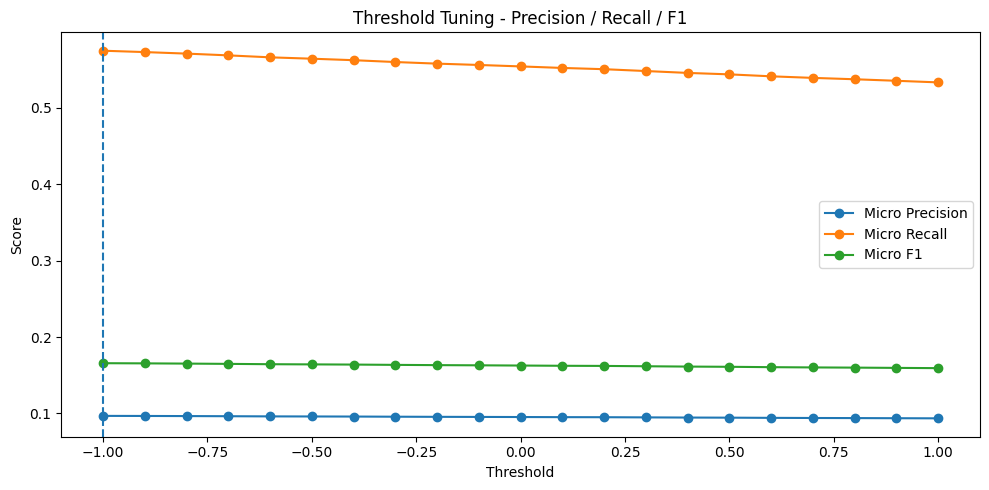

In [12]:
# ============================================================
# 12. PLOT PRECISION / RECALL / F1 VS THRESHOLD
# ============================================================

plot_df = threshold_results_df.sort_values("Threshold")

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Threshold"], plot_df["Micro Precision"], marker="o", label="Micro Precision")
plt.plot(plot_df["Threshold"], plot_df["Micro Recall"], marker="o", label="Micro Recall")
plt.plot(plot_df["Threshold"], plot_df["Micro F1"], marker="o", label="Micro F1")
plt.axvline(best_threshold, linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning - Precision / Recall / F1")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 13. SAVE TUNING OUTPUTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

threshold_results_df.to_csv(
    "../data/processed/structured_multilabel_candidate150_threshold_search.csv",
    index=False
)

pd.DataFrame([default_test_results]).to_csv(
    "../data/processed/structured_multilabel_candidate150_default_test_results.csv",
    index=False
)

pd.DataFrame([tuned_test_results]).to_csv(
    "../data/processed/structured_multilabel_candidate150_tuned_test_results.csv",
    index=False
)

np.save(
    "../data/processed/structured_multilabel_candidate150_tuned_y_test_pred.npy",
    Y_test_pred_tuned
)

with open("../data/processed/structured_multilabel_candidate150_best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("Saved threshold tuning outputs.")

Saved threshold tuning outputs.


In [14]:
# ============================================================
# 14. INTERPRETATION NOTES
# ============================================================

print("1. This notebook tunes the decision threshold for the best structured multi-label baseline.")
print("2. Threshold tuning is important because multi-label performance depends heavily on how aggressively labels are predicted.")
print("3. The best threshold was selected using validation Micro F1.")
print("4. The tuned threshold can now be used as the improved structured baseline for comparison with future audio multi-label models.")
print("5. After this step, the next decision will be whether the structured branch is strong enough to justify moving into audio multi-label modelling.")

1. This notebook tunes the decision threshold for the best structured multi-label baseline.
2. Threshold tuning is important because multi-label performance depends heavily on how aggressively labels are predicted.
3. The best threshold was selected using validation Micro F1.
4. The tuned threshold can now be used as the improved structured baseline for comparison with future audio multi-label models.
5. After this step, the next decision will be whether the structured branch is strong enough to justify moving into audio multi-label modelling.
